# Truth information and four-momentum conservation

> **Advanced extension.** Start with the [main lesson](w_to_munu_truth_met_69747.ipynb) on the visible muon, invisible neutrino, and missing transverse momentum. That lesson hid the generator-copy selection inside a Toolbox cell; here we open that Toolbox and study the event record in detail.

This notebook studies the primary high-energy interaction and a later $W$ decay in one file from the CMS simulated **W+jets** dataset [CERN Open Data record 69747](https://opendata.cern.ch/record/cms-69747).

The central question is whether energy and momentum before an interaction equal the totals afterward:

$$\sum_{\mathrm{incoming}} p^\mu = \sum_{\mathrm{outgoing}} p^\mu,$$

Here $p^\mu=(E,p_x,p_y,p_z)$. The superscript $\mu$ labels the four components; it does not mean “muon.”

We will ask two related but different questions:

1. **Global test:** do all incoming and outgoing particles in the primary high-energy interaction balance? For this, we use `LHEPart`.
2. **Local test:** does one final stored W stage balance with its direct decay products? For this, we use `GenPart`.

By the end, you should be able to choose the appropriate truth record, construct and add four-vectors, interpret small numerical differences, and follow repeated W rows without counting one particle several times.

The dataset contains electron, muon, and tau W decays. We will deliberately choose one unusually simple $W\to\mu\nu$ event so that the conservation calculation is easy to see.

## 1. Reminder: a diagram is not an event record

As in the main lesson, the pictures below are representative possibilities rather than photographs or complete histories. Read them from left to right: straight lines are quarks or leptons, curly lines are gluons, and wavy lines are W bosons.

| View | What it represents |
| --- | --- |
| Feynman diagram | A simplified contribution to the interaction calculation; it may draw a W that is not a stored row |
| `LHEPart` | Incoming and outgoing particles in the primary high-energy calculation |
| `GenPart` | A selected generator history after later stages and decays; successive copies of a particle may appear |

The production and decay panels can be joined at their W line, while `LHEPart` may list only the incoming and outgoing quarks, gluons, charged lepton, and neutrino. The [branch documentation for this exact file](https://opendata.cern.ch/eos/opendata/cms/dataset-semantics/NanoAODSIM/69747/WJetsToLNu_TuneCP5_13TeV-madgraphMLM-pythia8_doc.html) is the reference for the stored column meanings.

<details><summary>Technical generator description</summary>At the calculation stage the W is an internal propagator rather than an external row. The official [process card](https://opendata.cern.ch/eos/opendata/cms/lhe_generators/2016-sim/gridpacks/69747/InputCards/WJetsToLNu_13TeV-madgraphMLM-pythia8_proc_card.dat) includes $pp\to\ell\nu$ with zero to four outgoing matrix-element partons, combined with a parton shower using MLM matching. Compatible quantum amplitudes are added before probabilities are calculated.</details>

In [1]:
# @title Representative W production and decay diagrams
from IPython.display import HTML

diagram_base = "https://atlas.physicsmasterclasses.org/wpath_files/img/Feynman"
diagram_cards = [
    ("u + g → d + W⁺ (one-parton example)", f"{diagram_base}/WplusDown.png"),
    ("W⁺ → μ⁺ + νμ", f"{diagram_base}/Wplus_Antimyon.png"),
    ("d + g → u + W⁻ (one-parton example)", f"{diagram_base}/WminusUp.png"),
    ("W⁻ → μ⁻ + ν̄μ", f"{diagram_base}/Wminus_Myon.png"),
]
cards_html = "".join(
    f"<figure style='margin:0;text-align:center'><img src='{url}' alt='{caption}' "
    f"style='width:100%;max-height:260px;object-fit:contain'><figcaption>{caption}</figcaption></figure>"
    for caption, url in diagram_cards
)
HTML(
    f"<div style='display:grid;grid-template-columns:repeat(2,minmax(260px,1fr));gap:18px'>{cards_html}</div>"
    "<p style='font-size:0.85em;color:#475569'>Source and image credit: "
    "<a href='https://atlas.physicsmasterclasses.org/en/wpath_lhcphysics2.htm'>ATLAS W-Path, "
    "International Physics Masterclasses</a>. See the "
    "<a href='https://ippog.org/ippog-copyright'>IPPOG educational-use terms</a>.</p>"
)

## 2. Two truth records, two conservation tests

The protons collide at $\sqrt{s}=13\ \mathrm{TeV}$, so each proton beam has energy $E_{\rm beam}=6.5\ \mathrm{TeV}$. The primary collision is between **partons**—quarks or gluons—inside the protons. They carry event-dependent fractions $x_1$ and $x_2$ of the proton momenta:

$$p_1^\mu \simeq (x_1E_{\rm beam},0,0,+x_1E_{\rm beam}),\qquad
p_2^\mu \simeq (x_2E_{\rm beam},0,0,-x_2E_{\rm beam}).$$

The energy available to this parton collision is called $\sqrt{\hat{s}}$. The hat distinguishes it from the full 13 TeV proton–proton collision; for nearly massless incoming partons,

$$\sqrt{\hat{s}}\simeq 13\ \mathrm{TeV}\sqrt{x_1x_2}.$$

For a global conservation test, `LHEPart` is the clean record. Its status is `-1` for incoming particles and `1` for outgoing particles, and `LHEPart_incomingpz` stores the incoming longitudinal momentum. The later `GenPart` collection contains radiation and decay history, with multiple copies of some particles, but only the subset considered “interesting” by NanoAOD. Summing every `GenPart` would therefore double-count history entries while also omitting other particles.

Both are commonly called “truth,” but they describe different stages and neither is a literal, complete list of everything that physically happened.

## Setup

Run the next two Toolbox cells to install any missing packages, locate or download the 133 MB data file, and define display helpers. Their implementation is not part of the physics lesson.

In [2]:
# @title Toolbox: install packages and locate the data file
from pathlib import Path
import html
import importlib.util
import shutil
import subprocess
import sys

# Install only dependencies that are missing from the current environment.
required_packages = {
    "awkward": "awkward==2.12.0", "uproot": "uproot==5.7.5",
    "graphviz": "graphviz==0.21", "particle": "particle==1.0.0",
}
missing = [package for module, package in required_packages.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)
if shutil.which("dot") is None:
    if importlib.util.find_spec("google.colab") is not None:
        subprocess.run(["apt-get", "update", "-qq"], check=True)
        subprocess.run(["apt-get", "install", "-y", "-qq", "graphviz"], check=True)
    else:
        raise RuntimeError("Graphviz 'dot' is required (for example: brew install graphviz).")

import awkward as ak
import matplotlib.pyplot as plt
import numpy as np
import uproot
from graphviz import Digraph
from IPython.display import Markdown, display
from particle import Particle, ParticleNotFound

filename = "00702195-E707-3743-8BBA-57EB9DEE1DBA.root"
file_url = (
    "https://opendata.cern.ch/eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/"
    "WJetsToLNu_TuneCP5_13TeV-madgraphMLM-pythia8/NANOAODSIM/"
    "106X_mcRun2_asymptotic_v17-v1/270000/" + filename
)
# Reuse a local copy when available; otherwise download into the working directory.
candidates = [Path("data/69747") / filename, Path("../data/69747") / filename, Path(filename)]
file_path = next((path.resolve() for path in candidates if path.exists()), None)
if file_path is None:
    file_path = Path(filename).resolve()
    subprocess.run(["curl", "-L", "--fail", "--retry", "3", "--output", str(file_path), file_url], check=True)

print(f"Uproot {uproot.__version__}; Awkward {ak.__version__}")
print(f"Input: {file_path.name}")

Uproot 5.7.5; Awkward 2.12.0
Input: 00702195-E707-3743-8BBA-57EB9DEE1DBA.root


In [3]:
# @title Toolbox: particle names and table display
PARTICLE_NAMES = {
    1: "d", -1: "d̄", 2: "u", -2: "ū", 3: "s", -3: "s̄",
    4: "c", -4: "c̄", 5: "b", -5: "b̄", 21: "g",
    11: "e⁻", -11: "e⁺", 12: "νₑ", -12: "ν̄ₑ",
    13: "μ⁻", -13: "μ⁺", 14: "νμ", -14: "ν̄μ",
    15: "τ⁻", -15: "τ⁺", 16: "ντ", -16: "ν̄τ",
    22: "γ", 23: "Z", 24: "W⁺", -24: "W⁻",
}

def particle_name(pdg_id):
    return PARTICLE_NAMES.get(int(pdg_id), str(int(pdg_id)))

def display_table(headers, rows):
    lines = [
        "| " + " | ".join(headers) + " |",
        "| " + " | ".join("---" for _ in headers) + " |",
    ]
    lines.extend("| " + " | ".join(map(str, row)) + " |" for row in rows)
    display(Markdown("\n".join(lines)))

## 3. Read the primary-interaction record

Each event has its own `LHEPart` list. Status `-1` marks an incoming parton and status `1` marks an outgoing particle. The W decay always contributes a charged lepton and neutrino; this sample may also contain zero to four outgoing partons.

**Predict first:** How many incoming particles should every event contain? What minimum and maximum numbers of outgoing particles do you expect?

In [4]:
root_file = uproot.open(file_path)
events = root_file["Events"]

# LHEPart is jagged: each event has its own list of incoming and outgoing particles.
lhe_branches = [
    "event",
    "Generator_x1", "Generator_x2", "Generator_id1", "Generator_id2",
    "LHEPart_pt", "LHEPart_eta", "LHEPart_phi", "LHEPart_mass",
    "LHEPart_incomingpz", "LHEPart_pdgId", "LHEPart_status",
]
lhe = events.arrays(lhe_branches, library="ak")

incoming_counts = ak.num(lhe.LHEPart_pdgId[lhe.LHEPart_status == -1])
outgoing_counts = ak.num(lhe.LHEPart_pdgId[lhe.LHEPart_status == 1])
assert bool(ak.all(incoming_counts == 2))
print(f"Loaded {len(lhe):,} events")
print("Incoming particles per event: 2 (verified for every event)")
print("Outgoing particles per event range from", int(ak.min(outgoing_counts)),
      "to", int(ak.max(outgoing_counts)))

Loaded 133,692 events
Incoming particles per event: 2 (verified for every event)
Outgoing particles per event range from 2 to 6


> **Observation:** every event has two incoming partons. The outgoing count ranges from 2 to 6: the charged lepton and neutrino, plus as many as four outgoing partons.

## 4. Construct every LHE four-vector

The main lesson introduced the four-vector $(E,p_x,p_y,p_z)$. NanoAOD stores outgoing particles using $(p_T,\eta,\phi,m)$, so we convert coordinates before adding them:

For an outgoing particle described by $(p_T,\eta,\phi,m)$,

$$p_x=p_T\cos\phi,\quad p_y=p_T\sin\phi,\quad p_z=p_T\sinh\eta,\quad
E=\sqrt{(p_T\cosh\eta)^2+m^2}.$$

The hyperbolic functions $\sinh$ and $\cosh$ are simply the standard conversion from the directional coordinate $\eta$ to Cartesian momentum components; learners do not need to derive them for this lesson. Incoming partons have zero transverse momentum here, so their energy is calculated from the stored `incomingpz`.

The code builds one four-vector for every stored LHE particle, then forms separate incoming and outgoing sums. The **residual** is the incoming total minus the outgoing total; exact conservation would make every residual component zero.

In [5]:
# Convert compressed NanoAOD numbers to standard 64-bit precision before arithmetic.
pt = ak.values_astype(lhe.LHEPart_pt, np.float64)
eta = ak.values_astype(lhe.LHEPart_eta, np.float64)
phi = ak.values_astype(lhe.LHEPart_phi, np.float64)
mass = ak.values_astype(lhe.LHEPart_mass, np.float64)
incoming_pz = ak.values_astype(lhe.LHEPart_incomingpz, np.float64)

is_incoming = lhe.LHEPart_status == -1
is_outgoing = lhe.LHEPart_status == 1

p4 = ak.zip({
    "E": ak.where(
        is_incoming,
        np.sqrt(incoming_pz**2 + mass**2),
        np.sqrt((pt * np.cosh(eta))**2 + mass**2),
    ),
    "px": pt * np.cos(phi),
    "py": pt * np.sin(phi),
    "pz": ak.where(is_incoming, incoming_pz, pt * np.sinh(eta)),
})

def sum_four_vectors(mask):
    return ak.zip({field: ak.sum(p4[field][mask], axis=1) for field in p4.fields})

incoming_total = sum_four_vectors(is_incoming)
outgoing_total = sum_four_vectors(is_outgoing)
residual = ak.zip({
    field: incoming_total[field] - outgoing_total[field]
    for field in p4.fields
})

## 5. One especially clear event

We select a primary interaction with exactly two outgoing LHE particles: one muon and one muon-neutrino. We also require $|\eta|<2.5$ so both directions are not extremely close to the beam, and choose $x_1$ and $x_2$ within about 20% of one another so the outgoing system has only a modest longitudinal motion. These choices make the arithmetic and vector picture especially easy to read.

A row **index** is its position within this event. A **PDG ID** is a standard signed number identifying the particle type; the table translates each ID into a particle name.

**Predict first:** With only two outgoing particles, how should their transverse vectors be related? Should their individual longitudinal momenta also be equal and opposite?

<details><summary>Why call this event unusually simple?</summary>“No outgoing LHE parton” does not mean that later generator stages contain no radiation or that the reconstructed event contains no jets. In a general W+jets event, all outgoing particles balance together; the muon and neutrino need not be back-to-back.</details>

In [6]:
# Pick a visually simple μν event for the worked four-momentum example.
outgoing_abs_id = abs(lhe.LHEPart_pdgId[is_outgoing])
outgoing_muon_count = ak.sum(outgoing_abs_id == 13, axis=1)
outgoing_muon_neutrino_count = ak.sum(outgoing_abs_id == 14, axis=1)
is_simple_muon_event = (
    (ak.num(outgoing_abs_id, axis=1) == 2)
    & (outgoing_muon_count == 1)
    & (outgoing_muon_neutrino_count == 1)
    & ak.all(abs(lhe.LHEPart_eta[is_outgoing]) < 2.5, axis=1)
    & (abs(np.log(lhe.Generator_x1 / lhe.Generator_x2)) < 0.2)
)
event_index = int(np.flatnonzero(ak.to_numpy(is_simple_muon_event))[0])

print(f"Entry {event_index}; event number {int(lhe.event[event_index])}")
print(f"x₁ = {float(lhe.Generator_x1[event_index]):.6f}")
print(f"x₂ = {float(lhe.Generator_x2[event_index]):.6f}")

Entry 42; event number 6053913
x₁ = 0.005875
x₂ = 0.006526


In [7]:
particle_rows = []
for particle_index in range(len(lhe.LHEPart_pdgId[event_index])):
    role = "incoming" if bool(is_incoming[event_index, particle_index]) else "outgoing"
    particle_rows.append([
        particle_index,
        role,
        particle_name(lhe.LHEPart_pdgId[event_index, particle_index]),
        int(lhe.LHEPart_pdgId[event_index, particle_index]),
        f"{float(p4.E[event_index, particle_index]):.4f}",
        f"{float(p4.px[event_index, particle_index]):+.4f}",
        f"{float(p4.py[event_index, particle_index]):+.4f}",
        f"{float(p4.pz[event_index, particle_index]):+.4f}",
    ])

display_table(
    ["index", "role", "particle", "PDG ID", "E [GeV]", "px [GeV]", "py [GeV]", "pz [GeV]"],
    particle_rows,
)

| index | role | particle | PDG ID | E [GeV] | px [GeV] | py [GeV] | pz [GeV] |
| --- | --- | --- | --- | --- | --- | --- | --- |
| 0 | incoming | ū | -2 | 38.1836 | +0.0000 | +0.0000 | +38.1836 |
| 1 | incoming | d | 1 | 42.4199 | +0.0000 | +0.0000 | -42.4199 |
| 2 | outgoing | μ⁻ | 13 | 40.9108 | -38.0400 | +6.2304 | -13.7051 |
| 3 | outgoing | ν̄μ | -14 | 39.6931 | +38.0400 | -6.2305 | +9.4701 |

In [8]:
balance_rows = []
for label, total in [
    ("Σ incoming", incoming_total),
    ("Σ outgoing", outgoing_total),
    ("incoming − outgoing", residual),
]:
    balance_rows.append([
        label,
        *[f"{float(total[field][event_index]):+.6f}" for field in ["E", "px", "py", "pz"]],
    ])

display_table(["sum", "E [GeV]", "px [GeV]", "py [GeV]", "pz [GeV]"], balance_rows)

def invariant_mass(total):
    mass_squared = total.E**2 - total.px**2 - total.py**2 - total.pz**2
    return np.sqrt(np.maximum(ak.to_numpy(mass_squared), 0.0))

mass_in = invariant_mass(incoming_total)
mass_out = invariant_mass(outgoing_total)
sqrt_s_from_x = 13_000.0 * np.sqrt(
    ak.to_numpy(lhe.Generator_x1) * ak.to_numpy(lhe.Generator_x2)
)

print(f"Energy available to colliding partons, √ŝ (from four-vector): {mass_in[event_index]:.4f} GeV")
print(f"Energy available to colliding partons, √ŝ (from x₁x₂):       {sqrt_s_from_x[event_index]:.4f} GeV")
print(f"Invariant mass of outgoing system:       {mass_out[event_index]:.4f} GeV")

| sum | E [GeV] | px [GeV] | py [GeV] | pz [GeV] |
| --- | --- | --- | --- | --- |
| Σ incoming | +80.603516 | +0.000000 | +0.000000 | -4.236328 |
| Σ outgoing | +80.603903 | -0.000008 | -0.000049 | -4.235009 |
| incoming − outgoing | -0.000387 | +0.000008 | +0.000049 | -0.001319 |

Energy available to colliding partons, √ŝ (from four-vector): 80.4921 GeV
Energy available to colliding partons, √ŝ (from x₁x₂):       80.4943 GeV
Invariant mass of outgoing system:       80.4926 GeV


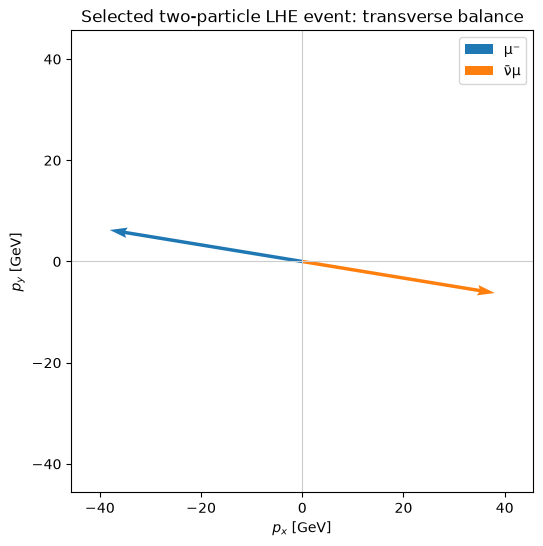

In [9]:
fig, ax = plt.subplots(figsize=(6, 6))
outgoing_indices = np.flatnonzero(ak.to_numpy(is_outgoing[event_index]))

colors = plt.get_cmap("tab10").colors
for display_index, particle_index in enumerate(outgoing_indices):
    px_value = float(p4.px[event_index, particle_index])
    py_value = float(p4.py[event_index, particle_index])
    label = particle_name(lhe.LHEPart_pdgId[event_index, particle_index])
    ax.quiver(
        0, 0, px_value, py_value,
        angles="xy", scale_units="xy", scale=1,
        color=colors[display_index % len(colors)], label=label,
    )

limit = 1.2 * max(
    float(ak.max(abs(p4.px[event_index][is_outgoing[event_index]]))),
    float(ak.max(abs(p4.py[event_index][is_outgoing[event_index]]))),
)
ax.set(xlim=(-limit, limit), ylim=(-limit, limit), xlabel="$p_x$ [GeV]", ylabel="$p_y$ [GeV]")
ax.axhline(0, color="0.8", linewidth=0.8)
ax.axvline(0, color="0.8", linewidth=0.8)
ax.set_aspect("equal")
ax.legend()
ax.set_title("Selected two-particle LHE event: transverse balance")
plt.show()

### What this event shows

- The incoming partons carry about 38.2 and 42.4 GeV, far less than the 6.5 TeV carried by each proton beam.
- Their longitudinal momenta point in opposite directions but are not equal, leaving a total $p_z$ of about $-4.24$ GeV. The outgoing system has the same total.
- The muon and neutrino transverse vectors are equal and opposite because these are the only two outgoing LHE particles in this selected event.
- Incoming and outgoing energies and all three momentum components agree to within a few thousandths of a GeV or better.
- Both methods give $\sqrt{\hat{s}}\approx80.49$ GeV, close to the W mass and dramatically smaller than the full 13 TeV proton-collision energy.

> **Takeaway:** conservation applies to the complete incoming and outgoing systems. The especially simple two-particle event lets us see the balance one vector at a time.

## 6. Four-momentum balance in every event

We now repeat the test for every event. For each component $a$, use the total incoming energy as the event scale and calculate

$$r_a=\frac{|\sum p^a_{\rm in}-\sum p^a_{\rm out}|}{\sum E_{\rm in}},
\qquad a\in\{E,p_x,p_y,p_z\}.$$

This is a separate relative difference for each component, not the length of one four-vector. NanoAOD compresses these numbers by storing them with limited precision, so the saved values are slightly rounded. The residual therefore measures storage precision as well as the balance produced by the generator.

**Predict first:** Should the incoming-versus-outgoing mass points lie near the diagonal? How small would a relative difference of $10^{-4}$ be as a percentage?

In [10]:
relative_residual = {
    field: abs(ak.to_numpy(residual[field])) / ak.to_numpy(incoming_total.E)
    for field in p4.fields
}

summary_rows = []
for field in ["E", "px", "py", "pz"]:
    q50, q90, q99, maximum = np.quantile(relative_residual[field], [0.50, 0.90, 0.99, 1.00])
    summary_rows.append([field, f"{q50:.2e}", f"{q90:.2e}", f"{q99:.2e}", f"{maximum:.2e}"])

display_table(["component", "median", "90th percentile", "99th percentile", "maximum"], summary_rows)

| component | median | 90th percentile | 99th percentile | maximum |
| --- | --- | --- | --- | --- |
| E | 2.08e-05 | 5.94e-05 | 1.10e-04 | 2.47e-04 |
| px | 1.17e-06 | 6.56e-06 | 1.82e-05 | 3.21e-05 |
| py | 1.22e-06 | 8.47e-06 | 1.88e-05 | 3.15e-05 |
| pz | 1.97e-05 | 5.92e-05 | 1.10e-04 | 2.46e-04 |

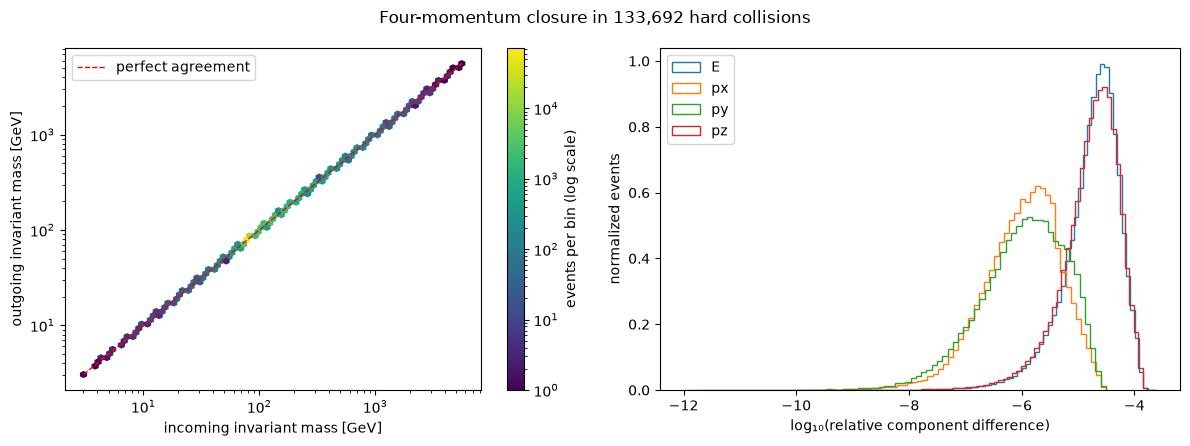

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

positive_mass = (mass_in > 0) & (mass_out > 0)
plot_limits = [
    min(mass_in[positive_mass].min(), mass_out[positive_mass].min()),
    max(mass_in[positive_mass].max(), mass_out[positive_mass].max()),
]
hexbin = axes[0].hexbin(
    mass_in[positive_mass], mass_out[positive_mass],
    gridsize=65, bins="log", mincnt=1, xscale="log", yscale="log",
)
axes[0].plot(plot_limits, plot_limits, "r--", linewidth=1, label="perfect agreement")
axes[0].set(xlabel="incoming invariant mass [GeV]", ylabel="outgoing invariant mass [GeV]")
axes[0].legend()
fig.colorbar(hexbin, ax=axes[0], label="events per bin (log scale)")

for field in ["E", "px", "py", "pz"]:
    log_residual = np.log10(np.clip(relative_residual[field], 1e-12, None))
    axes[1].hist(log_residual, bins=80, histtype="step", density=True, label=field)
axes[1].set(xlabel="log₁₀(relative component difference)", ylabel="normalized events")
axes[1].legend()

fig.suptitle(f"Four-momentum closure in {len(lhe):,} hard collisions")
fig.tight_layout()
plt.show()

### How to read the all-event results

- In the left plot, the dashed diagonal represents perfect incoming–outgoing mass agreement. The logarithmic axes allow collisions with very different energies to appear together, while color shows the number of events in each region on another logarithmic scale.
- In the right plot, $\log_{10}(r)=-4$ means $r=10^{-4}=0.01\%$. The curves are normalized to equal total area, so compare their shapes rather than their event counts.
- The table shows that even the 99th-percentile energy and longitudinal-momentum differences are only about $1.1\times10^{-4}$, or $0.011\%$. The small nonzero values are consistent with the limited precision of the stored kinematic numbers.

> **Takeaway:** the primary-interaction record balances across all 133,692 events to much better than one tenth of one percent.

## 7. Open the `GenPart` Toolbox

In the main lesson, a hidden cell selected the final stored W stage. We now examine why that selection was necessary. After the primary calculation, the event generator develops the event through later radiation, particle formation, and decays. `GenPart` retains selected rows from that history, including several successive copies of the W.

The `genPartIdxMother` branch stores the row index of each particle's parent; NanoAOD uses the traditional term “mother” in this official branch name. Named flags such as `first copy`, `last copy`, and `from hard process` describe a row's role. Raw numerical status codes depend on the generator and are not values learners need to memorize.

The table keeps rows associated with the primary interaction. Follow the **parent index** from one row to the next to reconstruct the stored history.

**Predict first:** If several W rows are stages of one history, what pattern should their row and parent indices form?

<details><summary>Technical generator vocabulary</summary>The stages include the matrix-element calculation, parton showering, hadronization, and decays. `GenPart_statusFlags` stores many yes/no labels as individual bits: `isHardProcess` is bit 7, `fromHardProcess` bit 8, `isFirstCopy` bit 12, and `isLastCopy` bit 13. Named flags are generally easier to interpret than generator-dependent numerical status codes.</details>

In [12]:
# Read the detailed generator history only for the event selected above.
gen_branches = [
    "event", "GenPart_pdgId", "GenPart_status", "GenPart_statusFlags",
    "GenPart_genPartIdxMother", "GenPart_pt", "GenPart_eta",
    "GenPart_phi", "GenPart_mass",
]
gen = events.arrays(
    gen_branches,
    entry_start=event_index,
    entry_stop=event_index + 1,
    library="ak",
)[0]

FLAG_BITS = {
    7: "hard process",
    8: "from hard process",
    12: "first copy",
    13: "last copy",
}

def has_flag(flags, bit):
    return bool(int(flags) & (1 << bit))

def selected_flag_names(flags):
    return ", ".join(name for bit, name in FLAG_BITS.items() if has_flag(flags, bit))

In [13]:
history_rows = []
for index in range(len(gen.GenPart_pdgId)):
    flags = gen.GenPart_statusFlags[index]
    if has_flag(flags, 7) or has_flag(flags, 8):
        history_rows.append([
            index,
            int(gen.GenPart_genPartIdxMother[index]),
            particle_name(gen.GenPart_pdgId[index]),
            f"{float(gen.GenPart_pt[index]):.3f}",
            selected_flag_names(flags),
        ])

display_table(
    ["index", "parent index", "particle", "pT [GeV]", "selected flags"],
    history_rows,
)

| index | parent index | particle | pT [GeV] | selected flags |
| --- | --- | --- | --- | --- |
| 0 | -1 | ū | 0.000 | hard process, from hard process, first copy, last copy |
| 1 | -1 | d | 0.000 | hard process, from hard process, last copy |
| 2 | 0 | W⁻ | 0.000 | hard process, from hard process, first copy |
| 3 | 2 | W⁻ | 2.758 | from hard process |
| 4 | 3 | W⁻ | 3.617 | from hard process |
| 5 | 4 | W⁻ | 4.438 | from hard process |
| 6 | 5 | W⁻ | 3.586 | from hard process, last copy |
| 7 | 6 | μ⁻ | 36.750 | hard process, from hard process, first copy, last copy |
| 8 | 6 | ν̄μ | 40.375 | hard process, from hard process, first copy, last copy |

### How to read the history table

- Rows 0 and 1 are the two incoming partons and have no stored parent.
- W rows 2, 3, 4, 5, and 6 form one chain: each row points to the preceding W row as its parent.
- Rows 7 and 8 both point to W row 6, identifying the muon and neutrino as its direct decay products.
- The W's stored $p_T$ changes from one stage to the next as the generator develops the rest of the event. These rows are different snapshots, not additional physical W bosons.

> **Takeaway:** summing every row would count the W history several times. For a local decay test, select the last W copy and only its direct children.

## 8. Visualize the stored W decay chain

The diagram below turns the parent-index table into arrows. Starting at the first W row keeps the display focused on that W and its descendants.

- **Yellow:** successive W stages
- **Green:** stable generator particles
- **Blue:** other intermediate generator particles, if present
- **Arrow:** stored parent-to-child link

<details><summary>Rendering tools</summary>The Scikit-HEP `particle` package translates PDG IDs into names. The Python `graphviz` package and system `dot` renderer lay out the links as an inline SVG; the setup cell installs or checks them.</details>

In [14]:
# @title Toolbox: draw a selected GenPart parent-to-child tree
def pdg_name_from_library(pdg_id):
    """Return the PDG particle name, with a safe fallback for generator-specific IDs."""
    try:
        return Particle.from_pdgid(int(pdg_id)).name
    except ParticleNotFound:
        return f"PDG {int(pdg_id)}"

def descendant_indices(gen_particles, root_index):
    """Return root_index and all descendants linked through the stored parent indices."""
    parent_indices = np.asarray(ak.to_numpy(gen_particles.GenPart_genPartIdxMother), dtype=int)
    selected = {int(root_index)}
    while True:
        children = {index for index, parent_index in enumerate(parent_indices) if parent_index in selected}
        expanded = selected | children
        if expanded == selected:
            return selected
        selected = expanded

def draw_genpart_tree(gen_particles, root_index=None):
    """Draw GenPart parent links, optionally restricted to one particle's descendants."""
    particle_count = len(gen_particles.GenPart_pdgId)
    selected = (
        set(range(particle_count))
        if root_index is None
        else descendant_indices(gen_particles, root_index)
    )

    graph = Digraph(
        "genpart_decay",
        format="svg",
        graph_attr={"rankdir": "LR", "bgcolor": "transparent", "ranksep": "0.65"},
        node_attr={"shape": "box", "style": "rounded,filled", "fontname": "Helvetica"},
        edge_attr={"color": "#64748b", "arrowsize": "0.7"},
    )

    for index in sorted(selected):
        pdg_id = int(gen_particles.GenPart_pdgId[index])
        status = int(gen_particles.GenPart_status[index])
        pt_value = float(gen_particles.GenPart_pt[index])
        name = html.escape(pdg_name_from_library(pdg_id))

        if abs(pdg_id) in {23, 24, 25}:
            fill_color = "#fde68a"  # heavy bosons
        elif status == 1:
            fill_color = "#bbf7d0"  # stable generator particles
        else:
            fill_color = "#dbeafe"  # intermediate copies

        label = (
            f"<<B>{name}</B><BR/>"
            f"<FONT POINT-SIZE='10'>index {index}<BR/>pT = {pt_value:.2f} GeV</FONT>>"
        )
        graph.node(str(index), label=label, fillcolor=fill_color)

    for child_index in sorted(selected):
        parent_index = int(gen_particles.GenPart_genPartIdxMother[child_index])
        if parent_index in selected:
            graph.edge(str(parent_index), str(child_index))

    return graph

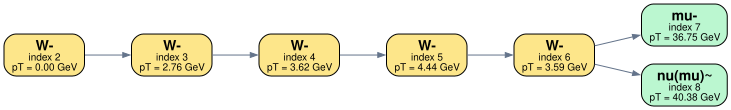

In [15]:
first_w_index = next(
    index for index in range(len(gen.GenPart_pdgId))
    if abs(int(gen.GenPart_pdgId[index])) == 24 and has_flag(gen.GenPart_statusFlags[index], 12)
)

draw_genpart_tree(gen, root_index=first_w_index)

## 9. Test conservation at the W decay

The global `LHEPart` test used every incoming and outgoing particle in the primary interaction. A global sum over `GenPart` would be wrong because it would count all five W stages. Instead, we make a **local** comparison: the last W row versus only its direct muon and neutrino children.

**Predict first:** Which four-vector components should match? Why might the stored values leave a small nonzero difference?

In [16]:
# Follow the W copy chain, then compare the last copy with its direct decay products.
w_descendants = descendant_indices(gen, first_w_index)
last_w_indices = [
    index for index in sorted(w_descendants)
    if abs(int(gen.GenPart_pdgId[index])) == 24 and has_flag(gen.GenPart_statusFlags[index], 13)
]
assert len(last_w_indices) == 1
w_index = last_w_indices[0]
decay_product_indices = np.flatnonzero(ak.to_numpy(gen.GenPart_genPartIdxMother == w_index))
assert sorted(abs(int(gen.GenPart_pdgId[index])) for index in decay_product_indices) == [13, 14]

def gen_four_vector(index):
    pt_value = float(gen.GenPart_pt[index])
    eta_value = float(gen.GenPart_eta[index])
    phi_value = float(gen.GenPart_phi[index])
    mass_value = float(gen.GenPart_mass[index])
    return np.array([
        np.sqrt((pt_value * np.cosh(eta_value))**2 + mass_value**2),
        pt_value * np.cos(phi_value),
        pt_value * np.sin(phi_value),
        pt_value * np.sinh(eta_value),
    ])

w_p4 = gen_four_vector(w_index)
decay_products_p4 = np.sum([gen_four_vector(index) for index in decay_product_indices], axis=0)
decay_residual = w_p4 - decay_products_p4

decay_rows = [
    [particle_name(gen.GenPart_pdgId[w_index]), *[f"{value:+.6f}" for value in w_p4]],
    [" + ".join(particle_name(gen.GenPart_pdgId[index]) for index in decay_product_indices),
     *[f"{value:+.6f}" for value in decay_products_p4]],
    ["parent − decay products", *[f"{value:+.6f}" for value in decay_residual]],
]
display_table(["system", "E [GeV]", "px [GeV]", "py [GeV]", "pz [GeV]"], decay_rows)
largest_decay_residual = np.max(abs(decay_residual) / w_p4[0])
print("Largest relative W-decay difference:",
      f"{largest_decay_residual:.2e} ({100 * largest_decay_residual:.3f}%)")

| system | E [GeV] | px [GeV] | py [GeV] | pz [GeV] |
| --- | --- | --- | --- | --- |
| W⁻ | +80.680680 | +3.476186 | -0.880387 | -4.032762 |
| μ⁻ + ν̄μ | +80.686852 | +3.523133 | -0.918157 | -4.017621 |
| parent − decay products | -0.006172 | -0.046947 | +0.037770 | -0.015140 |

Largest relative W-decay difference: 5.82e-04 (0.058%)


### Interpreting the local test

The last stored W and the sum of its muon and neutrino children agree in all four components. The largest relative difference is about $5.8\times10^{-4}$, or $0.058\%$. The local comparison reconstructs Cartesian components from several compressed $(p_T,\eta,\phi,m)$ values and follows selected generator-history rows, so a small stored difference is expected; it is not evidence that the physical decay violates conservation.

## Takeaways

- The 13 TeV proton collision does **not** put 13 TeV into each primary parton interaction. The two incoming partons carry fractions $x_1$ and $x_2$ of the beam momenta.
- The `LHEPart` incoming and outgoing systems have matching $E$, $p_x$, $p_y$, $p_z$, and invariant mass event by event.
- Small residuals remain because the NanoAOD file stores compressed kinematic values with limited precision.
- Generator histories contain successive copies and branches. Conservation should be tested either across the complete LHE primary interaction or locally at a well-defined parent-to-decay-products vertex—not by summing every `GenPart` row.

## Check your understanding

1. Why is the selected parton-collision energy near 80.5 GeV rather than 13 TeV?
2. Why can `LHEPart` be summed globally while the displayed `GenPart` rows cannot?
3. Convert a relative difference of $1.1\times10^{-4}$ into a percentage.
4. Which entries in the history table identify the final stored W and its two direct decay products?
5. In an event with an additional outgoing parton, must the muon and neutrino still be equal and opposite in the transverse plane?

<details><summary>Answers</summary>

1. Each colliding parton carries only a small fraction $x_1$ or $x_2$ of its proton's momentum. The full beam energy is not available to one parton–parton interaction.
2. `LHEPart` provides one set of incoming and outgoing rows for the primary calculation. `GenPart` stores selected history, including several stages of the same W, so a global sum would double-count that history and omit unrecorded particles.
3. Multiply by 100: $1.1\times10^{-4}=0.011\%$.
4. Row 6 is marked as the last W copy. Rows 7 and 8 both name row 6 as their parent and contain the muon and neutrino.
5. No. The vector sum of **all** outgoing transverse momenta must balance. Additional outgoing particles can recoil against the W system.

</details>

## Optional extensions

- Repeat the transverse-vector plot for an event with one outgoing LHE parton and show that all three outgoing vectors balance together.
- Compare the component residuals before and after rounding the stored kinematic values more aggressively.
- Draw the complete `GenPart` event and identify which branches are unrelated to the selected W history.